In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

## Gambaran Umum Dataset
- Memuat dataset
- Menampilkan bentuk dataset (shape)
- Menampilkan nama kolom
- Menampilkan tipe data
- Menampilkan 5 baris pertama

In [2]:
# Memuat dataset
df = pd.read_csv('data/DataCoSupplyChainDataset.csv', encoding='latin-1')

print("Bentuk Dataset:", df.shape)
print("\nNama Kolom:\n", df.columns.tolist())
print("\nTipe Data:\n", df.dtypes)
display(df.head())

Bentuk Dataset: (180519, 53)

Nama Kolom:
 ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price',

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## Penilaian Kualitas Data
- Analisis nilai yang hilang (missing values)
- Analisis baris duplikat
- Statistik deskriptif dasar
- Jumlah nilai unik untuk fitur kategorik

In [3]:
# Analisis nilai yang hilang
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Nilai yang Hilang:\n", missing_values)

# Analisis baris duplikat
duplicates = df.duplicated().sum()
print("\nBaris Duplikat:", duplicates)

# Statistik deskriptif dasar
display(df.describe().T)

# Jumlah nilai unik untuk fitur kategorik
cat_cols = df.select_dtypes(include=['object']).columns
unique_counts = {col: df[col].nunique() for col in cat_cols}
print("\nJumlah Nilai Unik untuk Fitur Kategorik:")
for col, count in sorted(unique_counts.items(), key=lambda x: x[1], reverse=True)[:15]: # Show top 15
    print(f"{col}: {count}")

Nilai yang Hilang:
 Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

Baris Duplikat: 0


,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933



Jumlah Nilai Unik untuk Fitur Kategorik:
order date (DateOrders): 65752
shipping date (DateOrders): 63701
Customer Street: 7458
Order City: 3597
Customer Lname: 1109
Order State: 1089
Customer Fname: 782
Customer City: 563
Order Country: 164
Product Image: 118
Product Name: 118
Category Name: 50
Customer State: 46
Order Region: 23
Department Name: 11


## Analisis Waktu
- Mengubah kolom tanggal pesanan menjadi format datetime
- Menganalisis rentang tanggal
- Visualisasi volume pesanan seiring waktu
- Visualisasi penjualan seiring waktu

Rentang Tanggal: Dari 2015-01-01 00:00:00 Sampai 2018-01-31 23:38:00


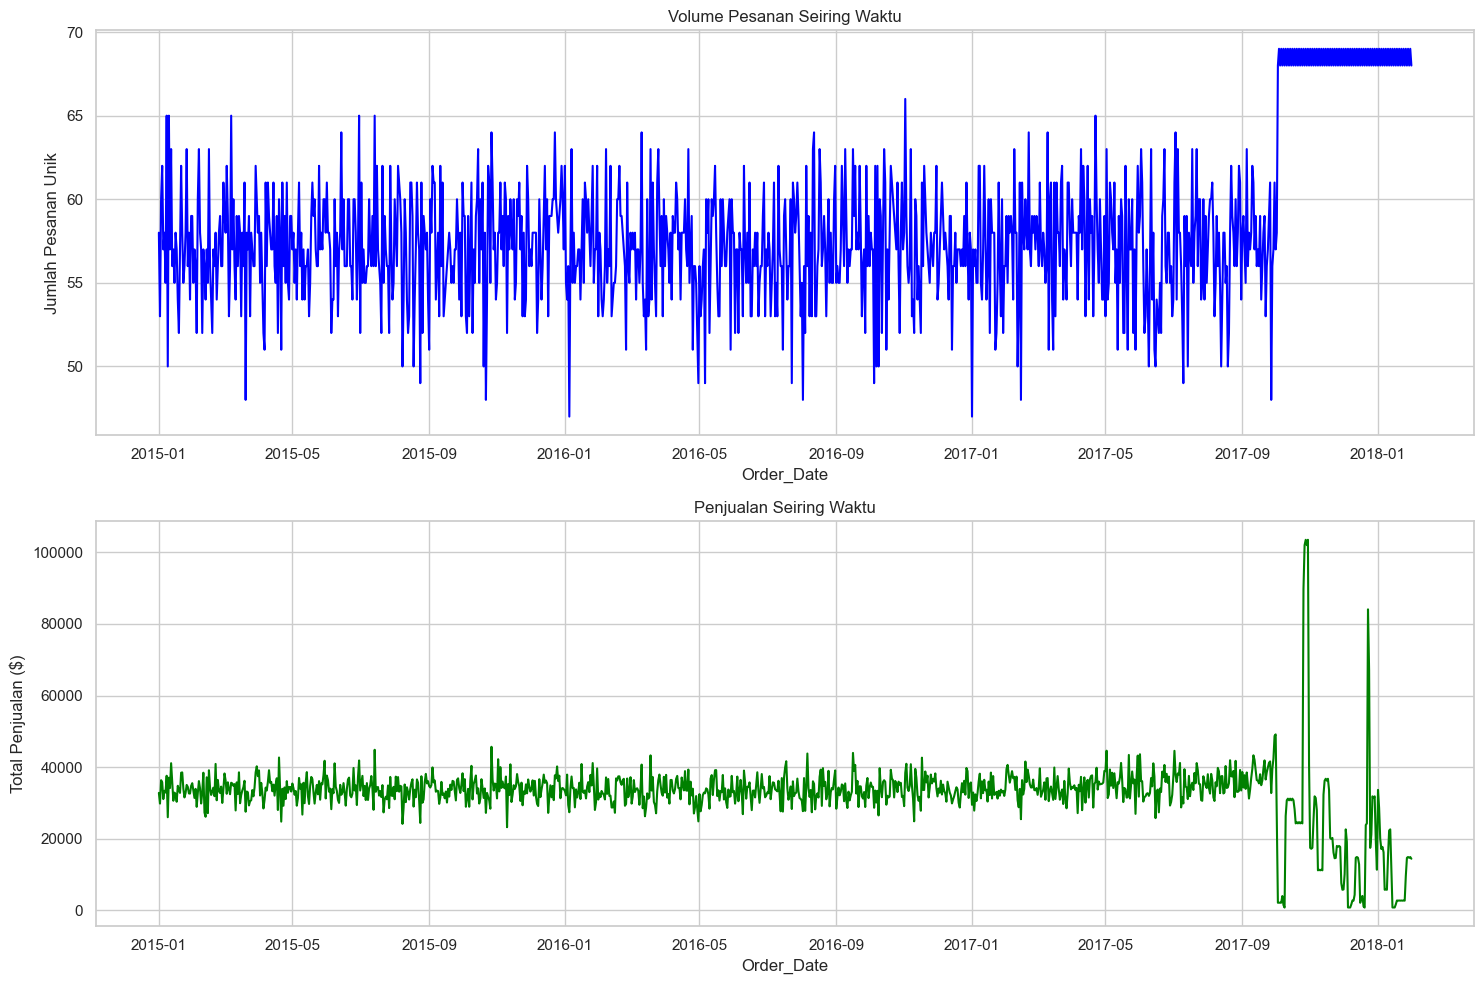

In [4]:
# Mengubah kolom tanggal pesanan menjadi datetime
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

print("Rentang Tanggal: Dari", df['order date (DateOrders)'].min(), "Sampai", df['order date (DateOrders)'].max())

# Membuat fitur berbasis waktu
df['Order_YearMonth'] = df['order date (DateOrders)'].dt.to_period('M')
df['Order_Date'] = df['order date (DateOrders)'].dt.date

# Pengelompokan berdasarkan Tanggal untuk volume dan penjualan
daily_volume = df.groupby('Order_Date')['Order Id'].nunique()
daily_sales = df.groupby('Order_Date')['Sales'].sum()

fig, ax = plt.subplots(2, 1, figsize=(15, 10))

# Plot volume pesanan seiring waktu
daily_volume.plot(ax=ax[0], color='blue', title='Volume Pesanan Seiring Waktu')
ax[0].set_ylabel('Jumlah Pesanan Unik')

# Plot penjualan seiring waktu
daily_sales.plot(ax=ax[1], color='green', title='Penjualan Seiring Waktu')
ax[1].set_ylabel('Total Penjualan ($)')

plt.tight_layout()
plt.show()

## Analisis Permintaan
- Distribusi penjualan/kuantitas pesanan
- Tren permintaan harian
- Tren permintaan bulanan
- Visualisasi tren musiman

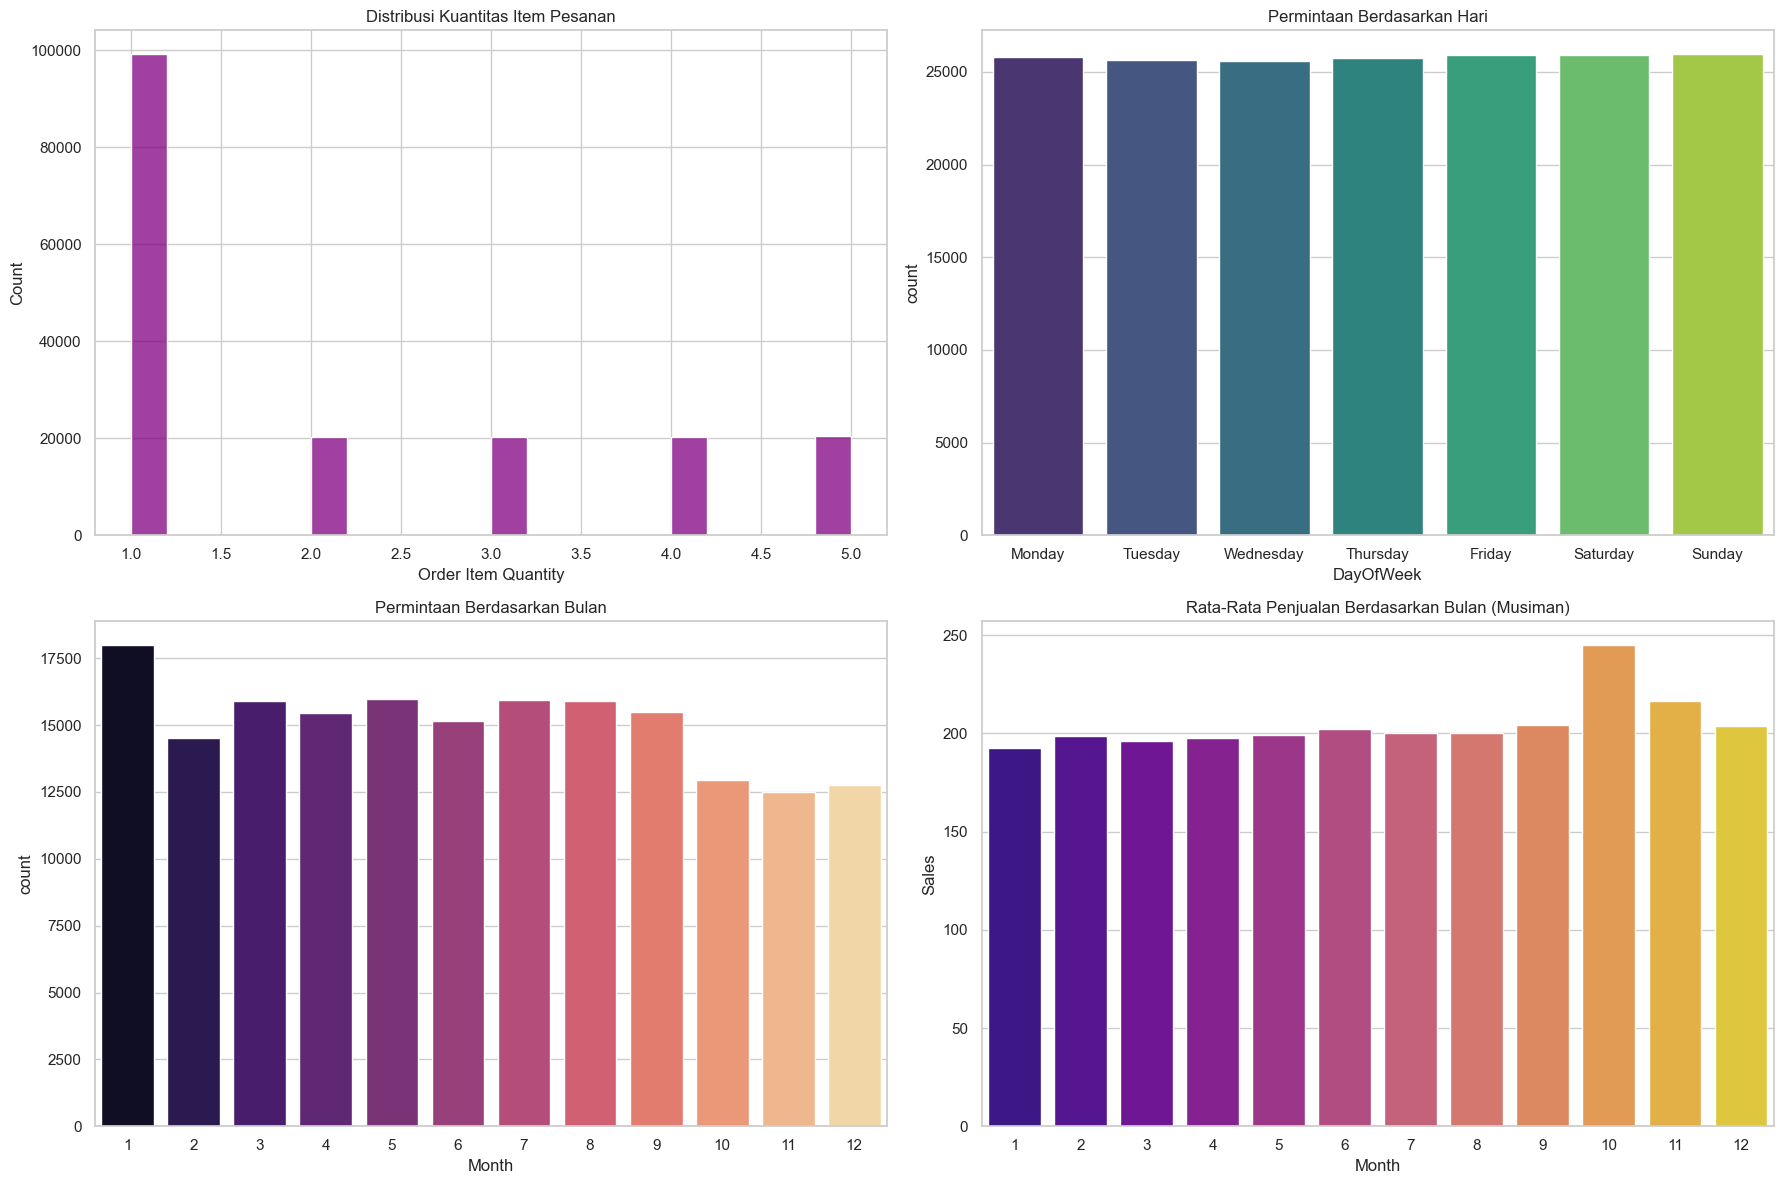

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# Distribusi Kuantitas Item Pesanan
sns.histplot(df['Order Item Quantity'], bins=20, ax=ax[0, 0], color='purple')
ax[0, 0].set_title('Distribusi Kuantitas Item Pesanan')

# Tren permintaan harian (Hari dalam Seminggu)
df['DayOfWeek'] = df['order date (DateOrders)'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(data=df, x='DayOfWeek', order=day_order, ax=ax[0, 1], palette='viridis')
ax[0, 1].set_title('Permintaan Berdasarkan Hari')

# Tren permintaan bulanan
df['Month'] = df['order date (DateOrders)'].dt.month
sns.countplot(data=df, x='Month', ax=ax[1, 0], palette='magma')
ax[1, 0].set_title('Permintaan Berdasarkan Bulan')

# Visualisasi tren musiman (Penjualan Berdasarkan Bulan)
monthly_sales = df.groupby('Month')['Sales'].mean().reset_index()
sns.barplot(data=monthly_sales, x='Month', y='Sales', ax=ax[1, 1], palette='plasma')
ax[1, 1].set_title('Rata-Rata Penjualan Berdasarkan Bulan (Musiman)')

plt.tight_layout()
plt.show()

## Analisis Rantai Pasok
- Distribusi mode pengiriman
- Distribusi status pengiriman
- Distribusi status pesanan
- Distribusi pasar (Market)
- Distribusi wilayah (Region)

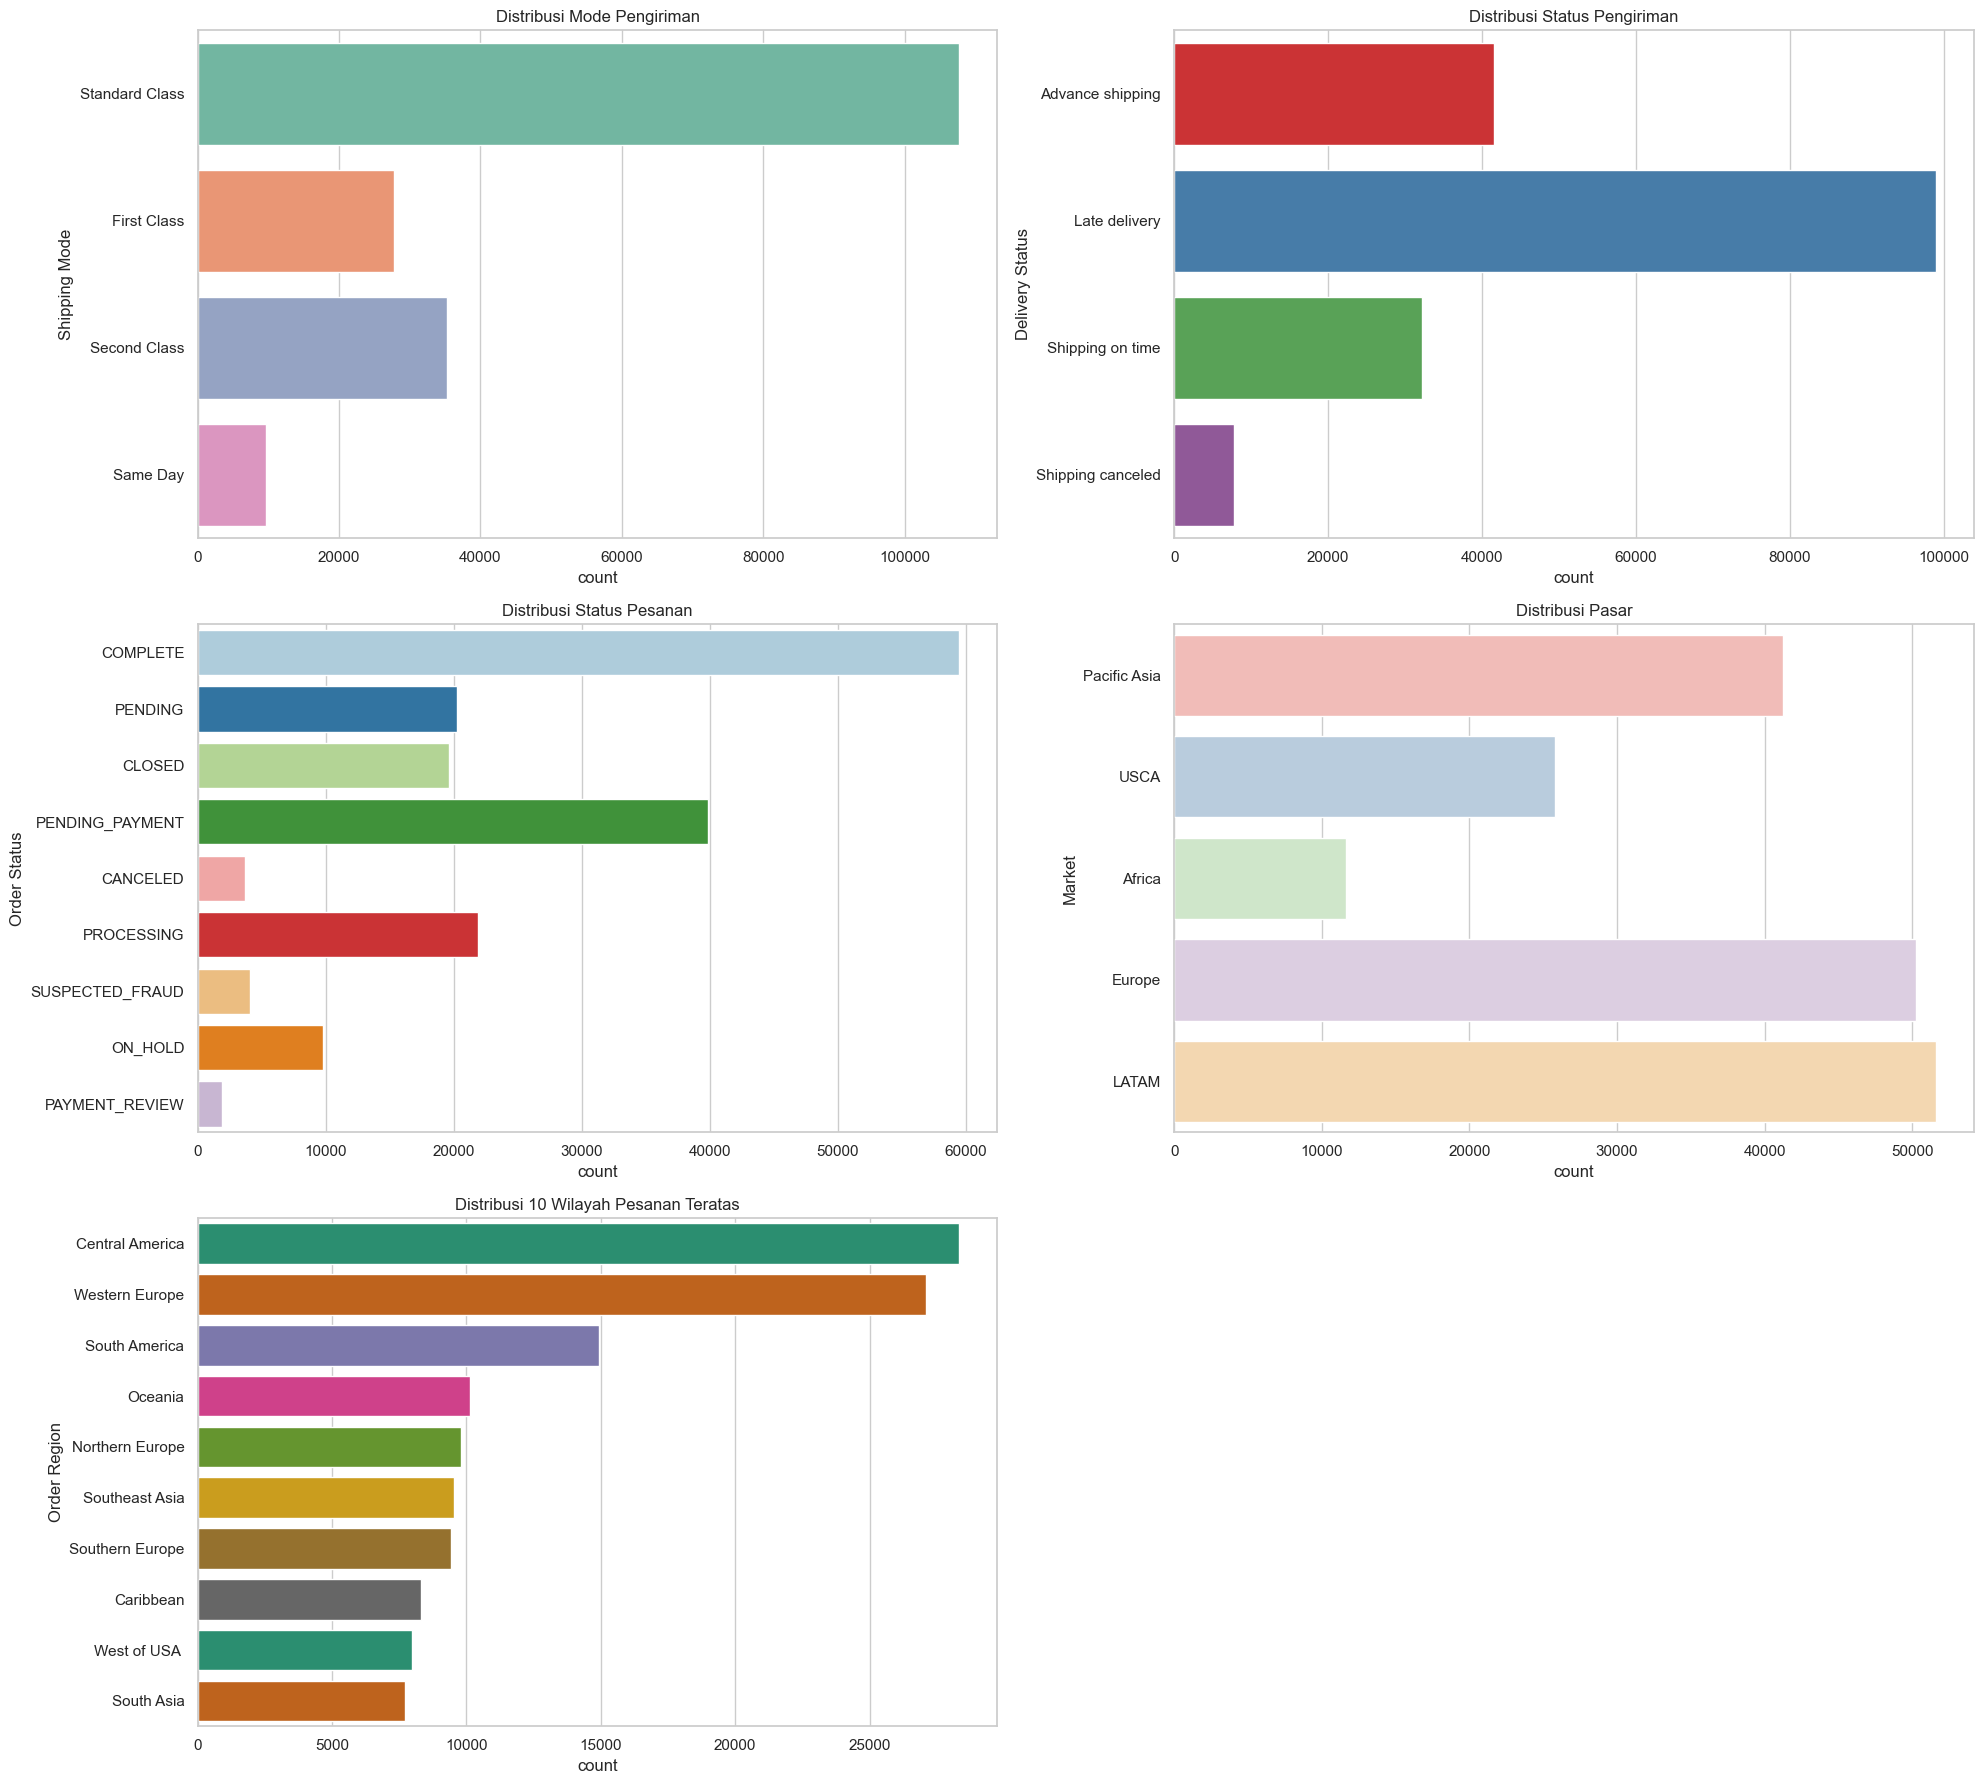

In [6]:
fig, ax = plt.subplots(3, 2, figsize=(20, 18))

# Distribusi mode pengiriman
sns.countplot(data=df, y='Shipping Mode', ax=ax[0, 0], palette='Set2')
ax[0, 0].set_title('Distribusi Mode Pengiriman')

# Distribusi status pengiriman
sns.countplot(data=df, y='Delivery Status', ax=ax[0, 1], palette='Set1')
ax[0, 1].set_title('Distribusi Status Pengiriman')

# Distribusi status pesanan
sns.countplot(data=df, y='Order Status', ax=ax[1, 0], palette='Paired')
ax[1, 0].set_title('Distribusi Status Pesanan')

# Distribusi pasar
sns.countplot(data=df, y='Market', ax=ax[1, 1], palette='Pastel1')
ax[1, 1].set_title('Distribusi Pasar')

# Distribusi wilayah (Top 10)
top_regions = df['Order Region'].value_counts().nlargest(10).index
sns.countplot(data=df[df['Order Region'].isin(top_regions)], y='Order Region', order=top_regions, ax=ax[2, 0], palette='Dark2')
ax[2, 0].set_title('Distribusi 10 Wilayah Pesanan Teratas')

ax[2, 1].axis('off') # Menyembunyikan subplot kosong

plt.tight_layout()
plt.show()

## Analisis Kinerja Logistik
- Mode pengiriman vs status pengiriman
- Mode pengiriman vs penjualan
- Analisis keterlambatan pengiriman
- Distribusi durasi pengiriman

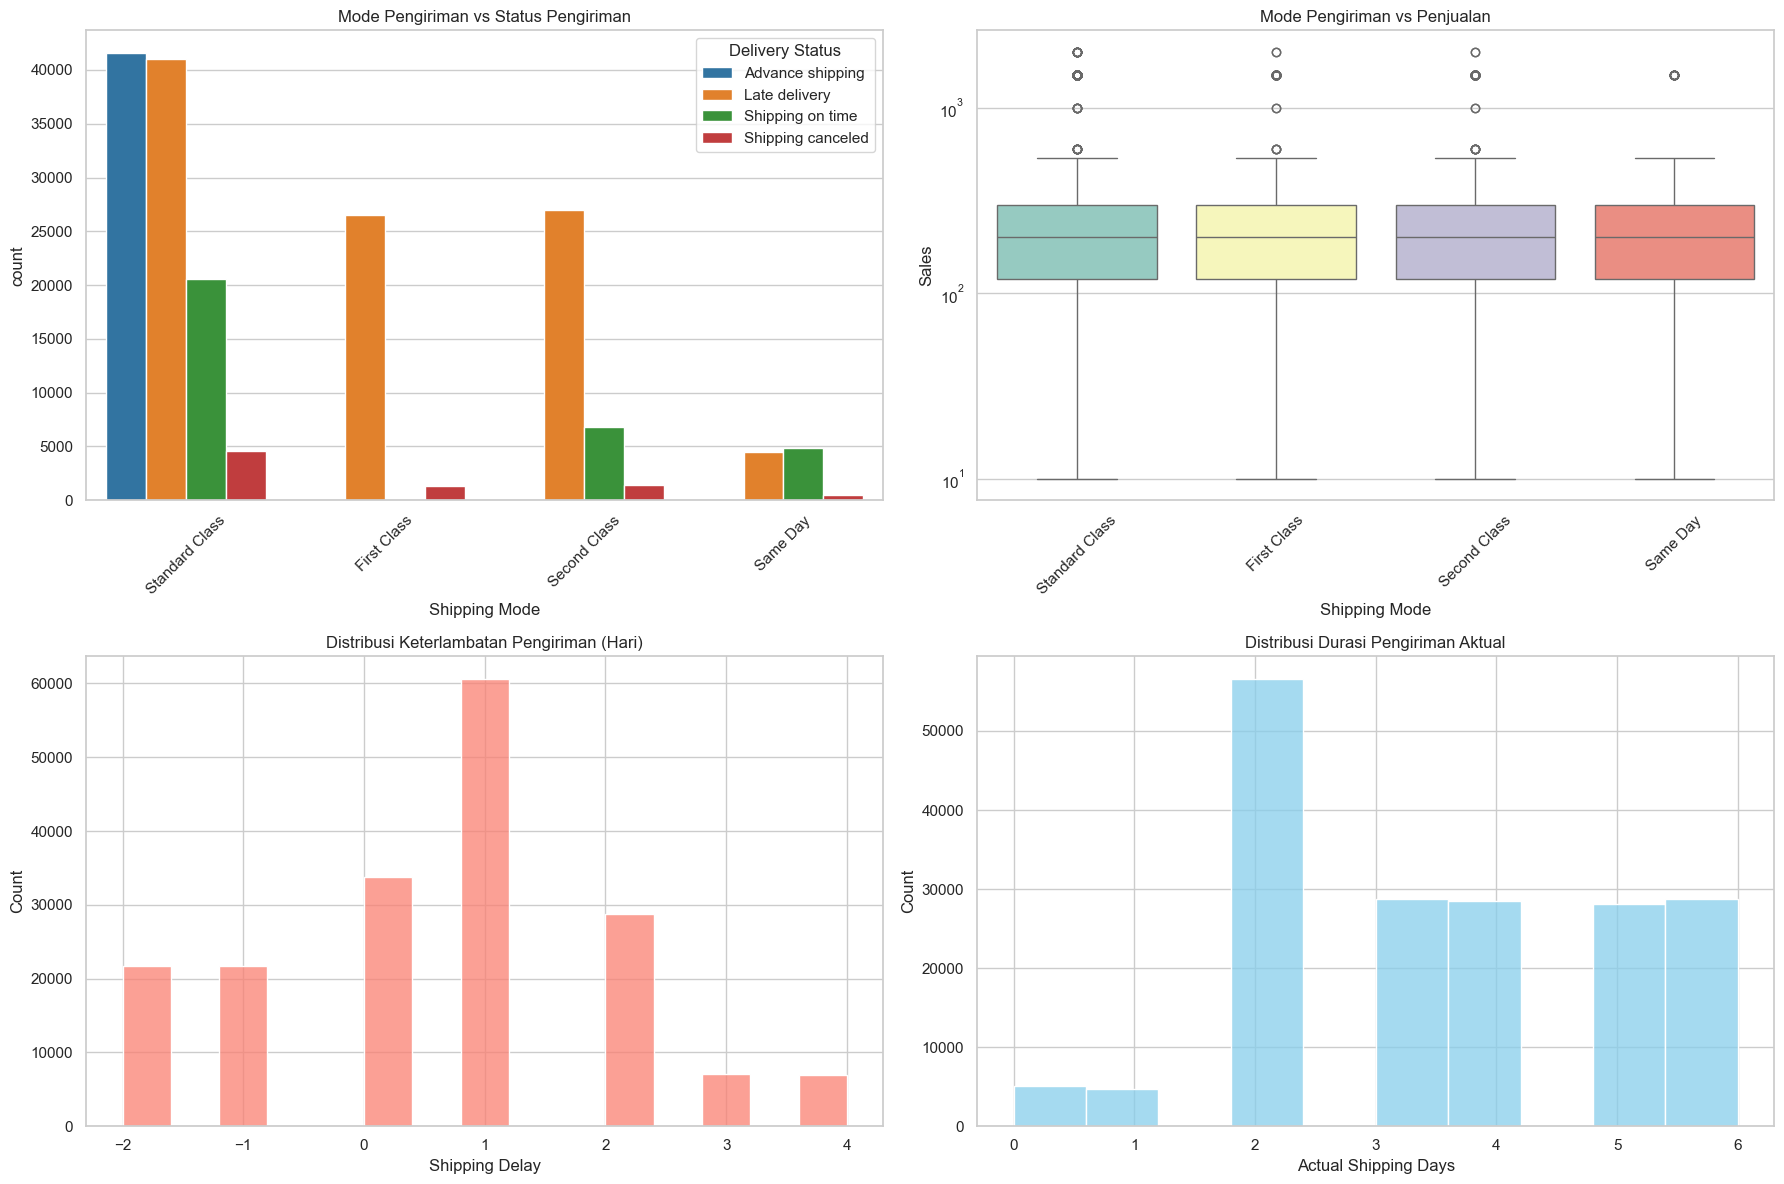

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# Mode pengiriman vs status pengiriman
sns.countplot(data=df, x='Shipping Mode', hue='Delivery Status', ax=ax[0, 0], palette='tab10')
ax[0, 0].set_title('Mode Pengiriman vs Status Pengiriman')
ax[0, 0].tick_params(axis='x', rotation=45)

# Mode pengiriman vs penjualan
sns.boxplot(data=df, x='Shipping Mode', y='Sales', ax=ax[0, 1], palette='Set3')
ax[0, 1].set_title('Mode Pengiriman vs Penjualan')
ax[0, 1].set_yscale('log') # Skala logaritmik agar lebih jelas
ax[0, 1].tick_params(axis='x', rotation=45)

# Menghitung durasi pengiriman (Keterlambatan)
df['Actual Shipping Days'] = df['Days for shipping (real)']
df['Scheduled Shipping Days'] = df['Days for shipment (scheduled)']
df['Shipping Delay'] = df['Actual Shipping Days'] - df['Scheduled Shipping Days']

# Distribusi keterlambatan pengiriman
sns.histplot(df['Shipping Delay'], bins=15, ax=ax[1, 0], color='salmon')
ax[1, 0].set_title('Distribusi Keterlambatan Pengiriman (Hari)')

# Distribusi hari pengiriman aktual
sns.histplot(df['Actual Shipping Days'], bins=10, ax=ax[1, 1], color='skyblue')
ax[1, 1].set_title('Distribusi Durasi Pengiriman Aktual')

plt.tight_layout()
plt.show()

## Analisis Korelasi
- Heatmap korelasi untuk variabel numerik
- Mengidentifikasi variabel yang berpotensi berguna untuk peramalan dan optimasi

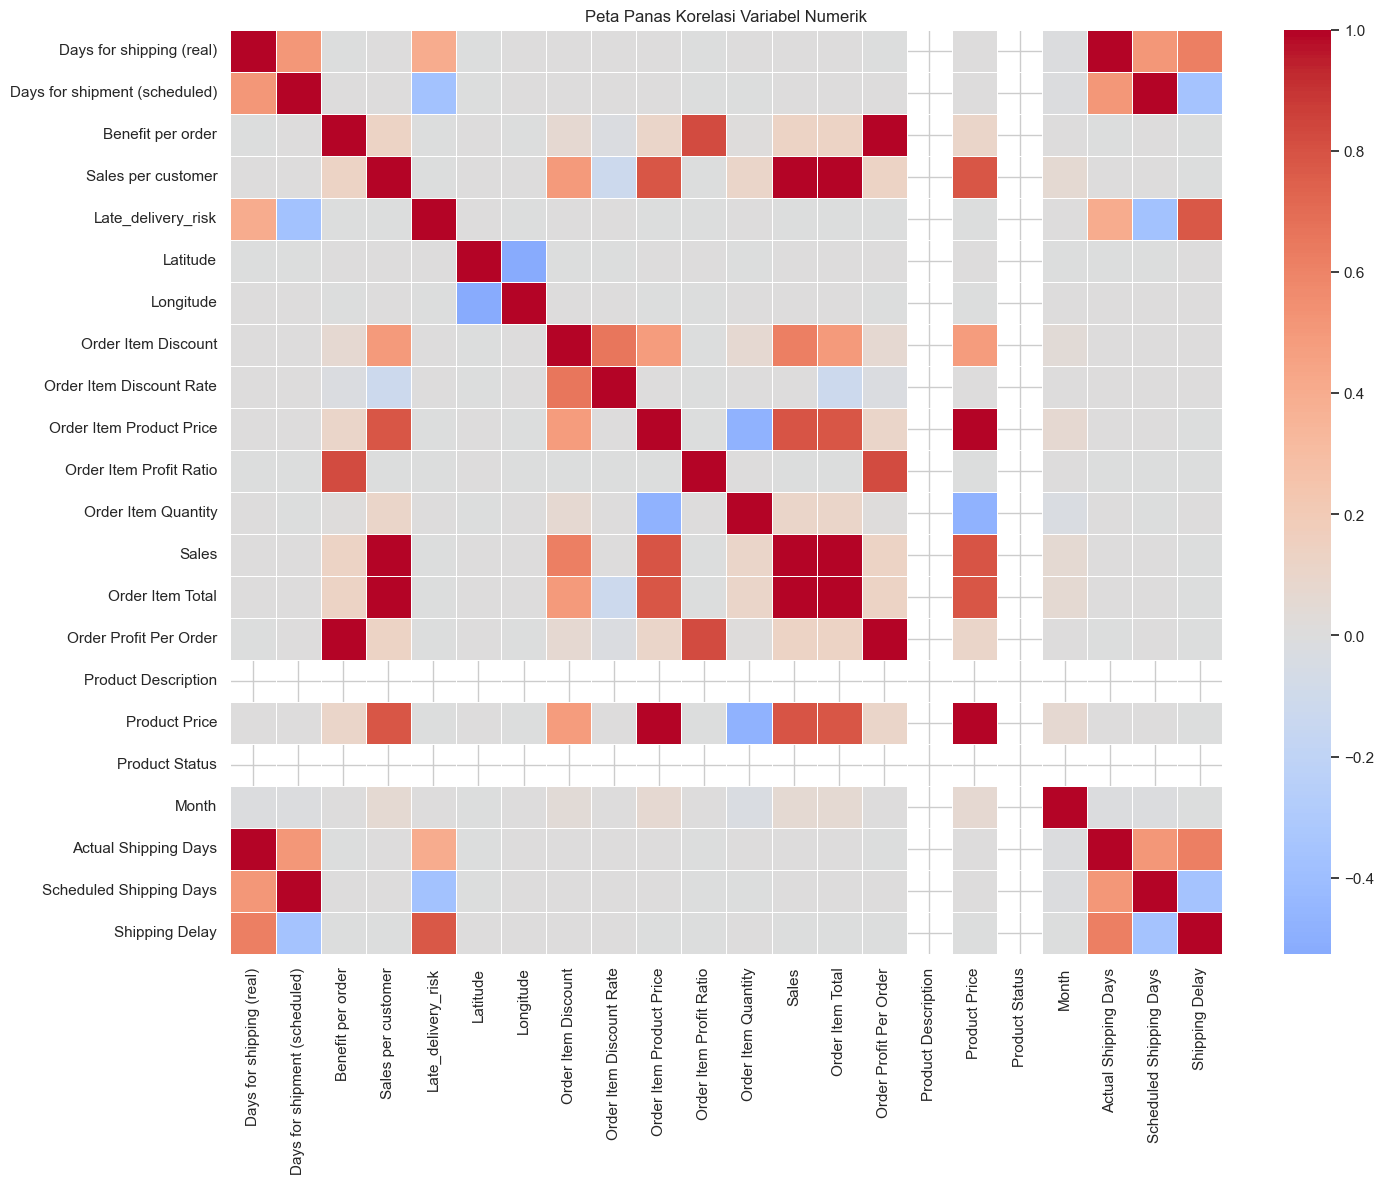

Korelasi tertinggi dengan Penjualan (Sales):
Sales                       1.000000
Sales per customer          0.989744
Order Item Total            0.989744
Order Item Product Price    0.789948
Product Price               0.789948
Order Item Discount         0.617438
Benefit per order           0.131816
Order Profit Per Order      0.131816
Order Item Quantity         0.106442
Month                       0.057534
Name: Sales, dtype: float64


In [8]:
# Memilih kolom numerik untuk korelasi
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Memfilter kolom ID atau fitur numerik yang tidak relevan agar heatmap lebih rapi
cols_to_drop = [col for col in numerical_cols if 'Id' in col or 'zipcode' in col.lower()]
corr_cols = [col for col in numerical_cols if col not in cols_to_drop]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Peta Panas Korelasi Variabel Numerik')
plt.show()

# Korelasi tertinggi dengan Penjualan
print("Korelasi tertinggi dengan Penjualan (Sales):")
sales_corr = corr_matrix['Sales'].sort_values(ascending=False)
print(sales_corr.head(10))